# SqueakView Scientific Run Analysis

This notebook audits acquisition timing, serial/TTL alignment, detections, NvDCF tracks, and pose keypoints from the current DeepStream 9.1 schema. It can visualize either the live inference outputs or a provenance-preserving offline re-inference result while always treating the run's `raw.mp4` and `frames.csv` as ground truth.


In [1]:
from pathlib import Path
import json
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from matplotlib.patches import Rectangle

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Select a run explicitly, or leave RUN_DIR=None to use runs/.latest_run.
RUN_DIR = None
# "live", "latest_offline", or a Path to one offline_inference result directory.
INFERENCE_RESULT = "live"

HERE = Path.cwd().resolve()
REPO_ROOT = next((p for p in [HERE, *HERE.parents] if (p / "pyproject.toml").exists()), HERE)
if RUN_DIR is None:
    RUN_DIR = Path((REPO_ROOT / "runs" / ".latest_run").read_text().strip()).resolve()
else:
    RUN_DIR = Path(RUN_DIR).expanduser().resolve()

if INFERENCE_RESULT == "live":
    RESULT_DIR = RUN_DIR
elif INFERENCE_RESULT == "latest_offline":
    candidates = sorted((RUN_DIR / "offline_inference").glob("*"), key=lambda p: p.stat().st_mtime)
    if not candidates:
        raise FileNotFoundError("No offline inference result exists for this run")
    RESULT_DIR = candidates[-1]
else:
    RESULT_DIR = Path(INFERENCE_RESULT).expanduser().resolve()
ANALYSIS_DIR = RESULT_DIR / "analysis"

print(f"RUN_DIR:      {RUN_DIR}")
print(f"RESULT_DIR:   {RESULT_DIR}")
print(f"ANALYSIS_DIR: {ANALYSIS_DIR}")


/home/jetson/Documents/SqueakView/.venv/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


RUN_DIR:      /home/jetson/Documents/SqueakView/runs/test_jp7.2/test1/test1_2026-07-24_11-56-19_ad2391
RESULT_DIR:   /home/jetson/Documents/SqueakView/runs/test_jp7.2/test1/test1_2026-07-24_11-56-19_ad2391
ANALYSIS_DIR: /home/jetson/Documents/SqueakView/runs/test_jp7.2/test1/test1_2026-07-24_11-56-19_ad2391/analysis


## Load Current Tables

The alignment directory supplies the common RP2040 time base. Object, keypoint, and track tables come from the selected inference result. Offline results therefore remain separate from—and directly comparable with—the live outputs.


In [2]:
def read_csv(path: Path) -> pd.DataFrame:
    return pd.read_csv(path) if path.exists() else pd.DataFrame()

def numeric(df: pd.DataFrame, columns) -> pd.DataFrame:
    for column in columns:
        if column in df:
            df[column] = pd.to_numeric(df[column], errors="coerce")
    return df

summary = json.loads((ANALYSIS_DIR / "alignment_summary.json").read_text())
all_df = read_csv(ANALYSIS_DIR / "aligned_all.csv")
frames = numeric(read_csv(ANALYSIS_DIR / "aligned_frames.csv"), [
    "raw_frame_index", "camera_frame_id", "ttl_count", "frame_rp2040_us", "frame_time_s",
    "frame_pts_ns", "frame_pts_s", "duration_ns", "has_ttl", "has_detection", "detection_count",
    "video_frame_index",
])
events = numeric(read_csv(ANALYSIS_DIR / "aligned_events.csv"), [
    "serial_index", "rp2040_time_us", "event_time_s", "count", "previous_frame_id",
    "offset_from_previous_frame_ms", "nearest_frame_id", "offset_from_nearest_frame_ms",
])
detections = numeric(read_csv(ANALYSIS_DIR / "aligned_detections.csv"), [
    "detection_index", "raw_frame_index", "camera_frame_id", "ttl_count", "detection_rp2040_us",
    "detection_time_s", "frame_pts_ns", "frame_pts_s", "raw_frame_mapping_ok",
    "raw_frame_mapping_pts_ns", "raw_frame_mapping_delta", "conf", "x", "y", "w", "h",
    "original_frame", "original_ts_us", "obj_id", "class_id",
])
objects = numeric(read_csv(RESULT_DIR / "objects.csv"), [
    "deepstream_frame_number", "source_sequence_index", "camera_frame_id", "camera_timestamp_ns",
    "gst_pts_ns", "class_id", "track_id", "detected_this_frame", "tracker_predicted",
    "detector_confidence", "tracker_confidence", "track_x", "track_y", "track_w", "track_h",
])
keypoints = numeric(read_csv(RESULT_DIR / "keypoints.csv"), [
    "deepstream_frame_number", "source_sequence_index", "camera_frame_id", "track_id", "class_id",
    "keypoint_index", "x_px", "y_px", "x_norm", "y_norm", "confidence", "visible",
])
tracks = numeric(read_csv(RESULT_DIR / "tracks.csv"), [
    "stream_id", "track_id", "class_id", "first_frame", "last_frame", "observed_frames",
    "predicted_frames", "total_rows",
])

frame_lookup = frames[["raw_frame_index", "camera_frame_id", "frame_time_s", "frame_pts_ns"]].drop_duplicates("raw_frame_index")
if not objects.empty:
    objects = objects.merge(frame_lookup, left_on="source_sequence_index", right_on="raw_frame_index", how="left", suffixes=("", "_ledger"))
if not keypoints.empty:
    keypoints = keypoints.merge(frame_lookup, left_on="source_sequence_index", right_on="raw_frame_index", how="left", suffixes=("", "_ledger"))

print(f"frames={len(frames):,} events={len(events):,} detections={len(detections):,}")
print(f"objects={len(objects):,} keypoints={len(keypoints):,} tracks={len(tracks):,}")
display(frames.head(3), objects.head(3), keypoints.head(3), tracks.head(3))


frames=884 events=1,832 detections=4,249
objects=4,249 keypoints=41,349 tracks=44


,camera_frame_id,raw_frame_index,ttl_count,frame_rp2040_us,frame_time_s,controller_unix_us,camera_timestamp_ns,frame_pts_ns,frame_pts_s,duration_ns,...,frame_host_monotonic_ns,ttl_host_unix_ns,ttl_host_monotonic_ns,raw_video_file,video_frame_index,video_mapping_source,status,has_ttl,has_detection,detection_count
0,20944,0,1,71684323574,0.000000,1784886237217254,266606847821080,0,0.000000,33333333,...,71515253167000,1784908585839940169,71515261412826,raw.mp4,0,single_file_frames_csv,ok,1,1,8
1,20945,1,2,71684358448,0.034874,1784886237252128,266606882692000,34870920,0.034871,33333333,...,71515288424000,1784908585887755741,71515309224845,raw.mp4,1,single_file_frames_csv,ok,1,1,9
2,20946,2,3,71684391195,0.067621,1784886237284875,266606915441000,67619920,0.067620,33333333,...,71515320498000,1784908585889632491,71515311099867,raw.mp4,2,single_file_frames_csv,ok,1,1,10


,observation_id,stream_id,deepstream_frame_number,source_sequence_index,camera_frame_id,camera_timestamp_ns,gst_pts_ns,class_id,class_label,track_id,...,track_x,track_y,track_w,track_h,pose_available,schema_version,raw_frame_index,camera_frame_id_ledger,frame_time_s,frame_pts_ns
0,s0:f0:o0,0,0,0,20944,266606847821080,0,0,mouse,NaN,...,0.000000,480.9375,146.671875,342.5625,1,2,0,20944,0.0,0
1,s0:f0:o1,0,0,0,20944,266606847821080,0,0,mouse,NaN,...,240.187500,839.2500,135.562500,201.3750,1,2,0,20944,0.0,0
2,s0:f0:o2,0,0,0,20944,266606847821080,0,0,mouse,NaN,...,279.421875,978.7500,518.203125,101.2500,1,2,0,20944,0.0,0


,observation_id,stream_id,deepstream_frame_number,source_sequence_index,camera_frame_id,track_id,class_id,class_label,keypoint_index,keypoint_name,...,x_norm,y_norm,confidence,visible,coordinate_space,source,raw_frame_index,camera_frame_id_ledger,frame_time_s,frame_pts_ns
0,s0:f0:o0,0,0,0,20944,NaN,0,mouse,0,nose,...,0.001697,0.680208,0.000239,0,source_pixels,detector,0,20944,0.0,0
1,s0:f0:o0,0,0,0,20944,NaN,0,mouse,1,head,...,0.000000,0.666667,0.000495,0,source_pixels,detector,0,20944,0.0,0
2,s0:f0:o0,0,0,0,20944,NaN,0,mouse,2,left_ear,...,0.007434,0.681250,0.002483,0,source_pixels,detector,0,20944,0.0,0


,stream_id,track_id,class_id,class_label,first_frame,last_frame,observed_frames,predicted_frames,total_rows
0,0,0,0,mouse,2,3,2,0,2
1,0,1,0,mouse,2,113,20,0,20
2,0,2,0,mouse,2,159,145,0,145


## Acquisition and Alignment Health

Inspect this before interpreting behavior. Ground-truth video/frame mismatches, frame gaps, missing TTL pairs, mapping fallbacks, or clock-tolerance failures must be resolved or explicitly qualified.


In [3]:
display(pd.Series(summary.get("counts", {}), name="value").to_frame())
display(pd.Series(summary.get("validation", {}), name="value").to_frame())
display(pd.Series(summary.get("frame_identity", {}), name="value").to_frame())

checks = {
    "frame_gaps_detected": summary.get("counts", {}).get("frame_gaps_detected"),
    "frames_missing_ttl": summary.get("counts", {}).get("frames_missing_ttl"),
    "drop_events": summary.get("counts", {}).get("drop_events"),
    "detection_mapping_failed_rows": summary.get("validation", {}).get("detection_mapping_failed_rows"),
    "detection_mapping_fallback_rows": summary.get("validation", {}).get("detection_mapping_fallback_rows"),
    "detection_pts_mismatch_count": summary.get("validation", {}).get("detection_pts_mismatch_count"),
}
for name, value in checks.items():
    if value not in (0, None):
        print(f"WARNING: {name}={value}")

if RESULT_DIR != RUN_DIR:
    offline_manifest = json.loads((RESULT_DIR / "offline_manifest.json").read_text())
    display(pd.Series({
        "status": offline_manifest.get("status"),
        "decoded_frames": offline_manifest.get("decoded_frames"),
        "expected_frames": offline_manifest.get("source", {}).get("expected_frames"),
        "model": offline_manifest.get("model_package", {}).get("name"),
        "video_sha256": offline_manifest.get("source", {}).get("video_sha256"),
    }, name="offline provenance").to_frame())
else:
    admission_path = RUN_DIR / "inference_admission.json"
    if admission_path.exists():
        display(pd.Series(json.loads(admission_path.read_text()), name="live admission").to_frame())


,value
aligned_all_rows,6965
camera_high_events,884
detections,4249
drop_events,0
frame_gaps_detected,0
frames_missing_ttl,0
recorded_frames,884
serial_rows,1832


,value
detection_mapping_failed_rows,0
detection_mapping_fallback_rows,0
detection_mapping_legacy_rows,0
detection_mapping_method_counts,{'flir_user_meta': 4249}
detection_missing_frames_sample,[]
detection_pts_mismatch_count,0
detection_pts_mismatches_sample,[]
detection_ts_mismatch_count,0
detection_ts_mismatches_sample,[]
detections_missing_frame_count,0


,value


,live admission
captured_frames,{'0': 884}
inference_admitted_frames,{'0': 884}
inference_skipped_frames,{'0': 0}
policy,capture_non_leaky_inference_leaky_downstream
schema_version,1.0


## Frame Timing

RP2040 `CAMERA_HIGH` is the acquisition reference. GStreamer PTS is shown as an independent recording-path interval check; target FPS is read from the run manifest rather than hard-coded.


,ttl_interval_ms,pts_interval_ms
count,883.000000,883.000000
mean,33.333623,33.333517
std,0.905523,0.905541
min,30.683000,30.682456
1%,32.667920,32.669308
5%,32.732000,32.732982
50%,32.806000,32.804248
95%,34.865000,34.866066
99%,34.913760,34.916835
max,35.862000,35.860952


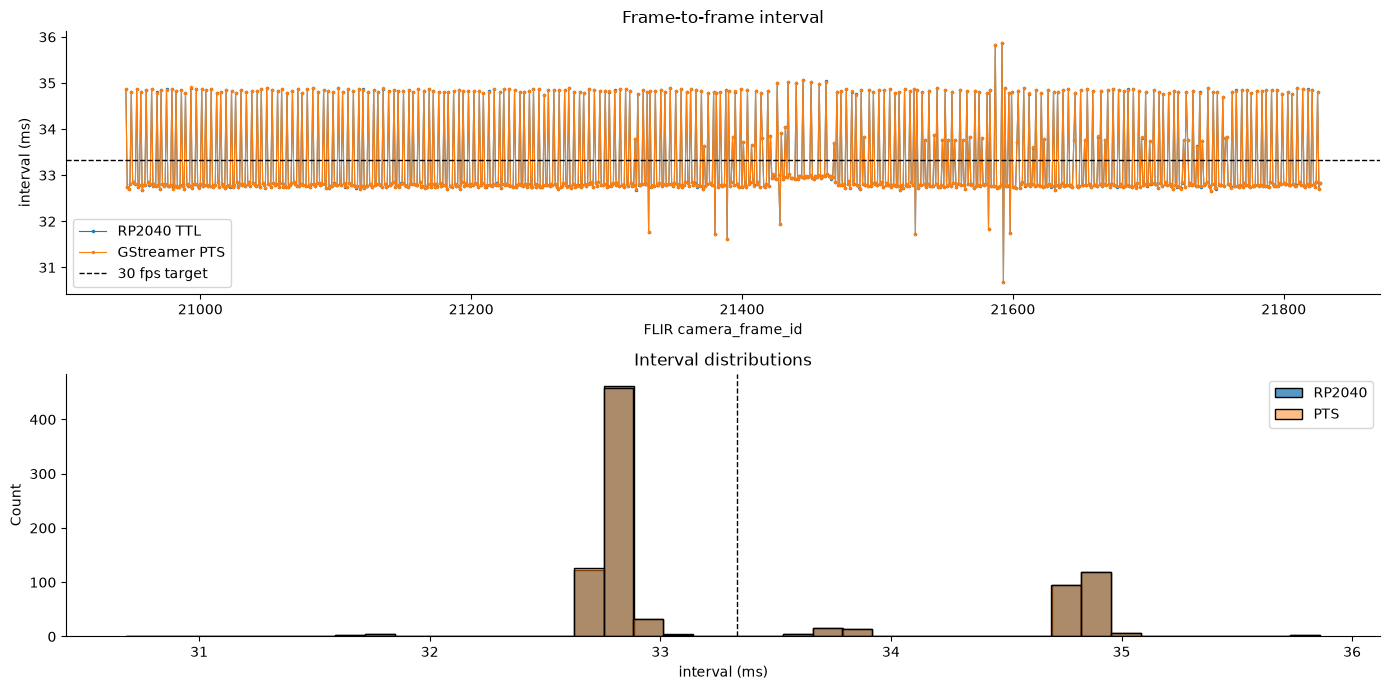

In [4]:
frames = frames.sort_values("camera_frame_id").reset_index(drop=True)
frames["ttl_interval_ms"] = frames["frame_rp2040_us"].diff() / 1_000.0
frames["pts_interval_ms"] = frames["frame_pts_ns"].diff() / 1_000_000.0
run_manifest = json.loads((RUN_DIR / "run_manifest.json").read_text())
fps = float(run_manifest.get("capture", {}).get("fps", 30))
expected_ms = 1_000.0 / fps

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
axes[0].plot(frames["camera_frame_id"], frames["ttl_interval_ms"], ".-", ms=3, lw=.8, label="RP2040 TTL")
axes[0].plot(frames["camera_frame_id"], frames["pts_interval_ms"], ".-", ms=3, lw=.8, label="GStreamer PTS")
axes[0].axhline(expected_ms, color="black", ls="--", lw=1, label=f"{fps:g} fps target")
axes[0].set(xlabel="FLIR camera_frame_id", ylabel="interval (ms)", title="Frame-to-frame interval")
axes[0].legend()
sns.histplot(frames["ttl_interval_ms"].dropna(), bins=40, ax=axes[1], label="RP2040", color="tab:blue")
sns.histplot(frames["pts_interval_ms"].dropna(), bins=40, ax=axes[1], label="PTS", color="tab:orange", alpha=.5)
axes[1].axvline(expected_ms, color="black", ls="--", lw=1)
axes[1].set(xlabel="interval (ms)", title="Interval distributions")
axes[1].legend()
plt.tight_layout()
display(frames[["ttl_interval_ms", "pts_interval_ms"]].describe(percentiles=[.01, .05, .5, .95, .99]))


## Inference Coverage and Serial Events

Detection coverage is aligned to every recorded frame. Tracker-predicted object rows are intentionally distinguished from detector observations.


,rows
detector observations,4249
tracker-only predictions,0


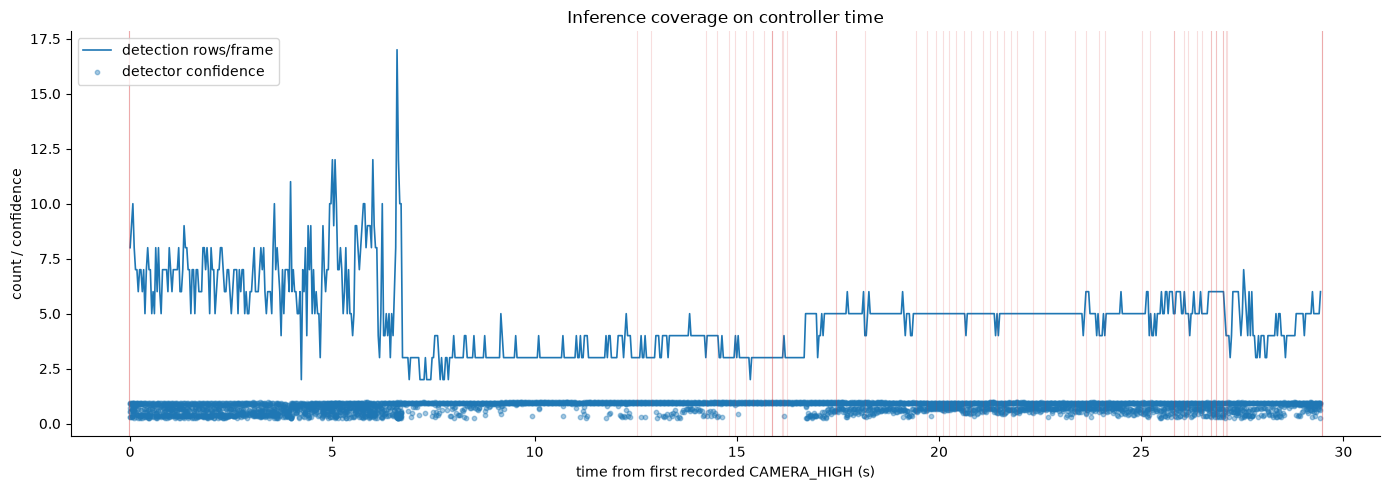

In [5]:
non_camera = events[~events["eventType"].isin(["CAMERA_HIGH", "CAMERA_LOW"])].dropna(subset=["event_time_s"])
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(frames["frame_time_s"], frames["detection_count"], lw=1.2, label="detection rows/frame")
if not detections.empty:
    ax.scatter(detections["detection_time_s"], detections["conf"], s=10, alpha=.4, label="detector confidence")
for _, row in non_camera.iterrows():
    ax.axvline(row["event_time_s"], color="tab:red", alpha=.15, lw=.8)
ax.set(xlabel="time from first recorded CAMERA_HIGH (s)", ylabel="count / confidence", title="Inference coverage on controller time")
ax.legend()
plt.tight_layout()

if not objects.empty:
    display(objects[["detected_this_frame", "tracker_predicted"]].sum().rename({
        "detected_this_frame": "detector observations", "tracker_predicted": "tracker-only predictions"
    }).to_frame("rows"))


## Serial Event Raster


,count
eventType,
POKE_START,15
POKE_END,15
DRINK_START,8
DRINK_END,8
ACK_START,1
STRIP_ON,1
LEFT_POKE_LIGHT_ON,1
FEED_START,1
TONE_START,1


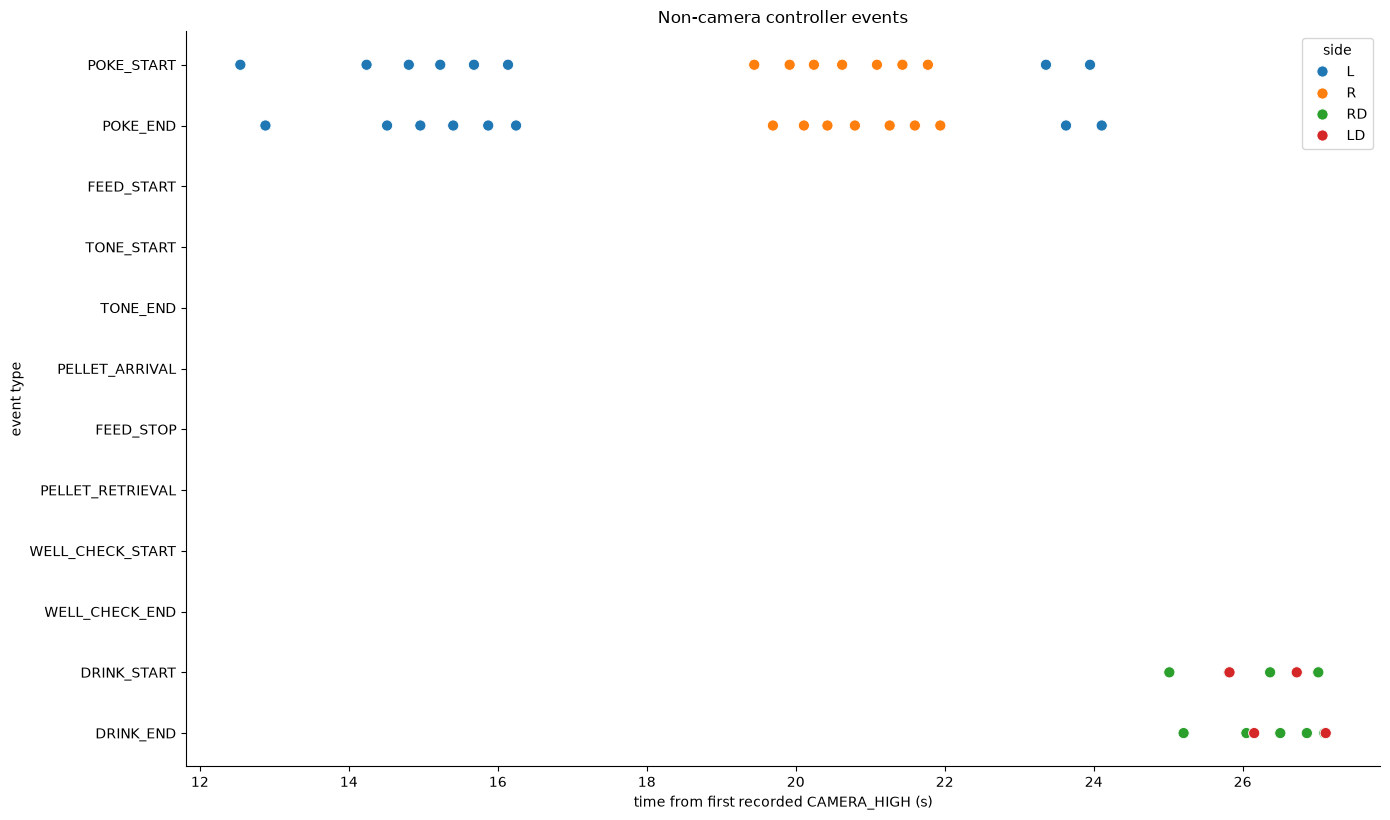

In [6]:
plot_events = events[~events["eventType"].isin(["CAMERA_HIGH", "CAMERA_LOW"])].dropna(subset=["event_time_s"]).copy()
if plot_events.empty:
    print("No non-camera serial events found.")
else:
    fig, ax = plt.subplots(figsize=(14, max(3, .35 * plot_events["eventType"].nunique() + 2)))
    sns.scatterplot(data=plot_events, x="event_time_s", y="eventType", hue="side" if "side" in plot_events else None, s=65, ax=ax)
    ax.set(xlabel="time from first recorded CAMERA_HIGH (s)", ylabel="event type", title="Non-camera controller events")
    plt.tight_layout()
    display(plot_events["eventType"].value_counts().to_frame("count"))


## Detection-to-Frame Mapping Proof

Live outputs should map by `flir_user_meta`; offline outputs should map by `offline_video_ledger`. Both methods preserve `source_sequence_index`/`raw_frame_num` and then use the dynamic per-run FLIR-to-RP2040 epoch in the aligner.


In [7]:
if detections.empty:
    print("No detections to audit.")
else:
    method_counts = detections["raw_frame_mapping_method"].fillna("missing").value_counts()
    display(method_counts.to_frame("rows"))
    map_check = detections.merge(
        frames[["camera_frame_id", "frame_pts_ns"]], on="camera_frame_id", how="left",
        suffixes=("_det", "_ledger"),
    )
    map_check["mapping_pts_delta_ns"] = map_check["raw_frame_mapping_pts_ns"] - map_check["frame_pts_ns_ledger"]
    problems = map_check[(map_check["raw_frame_mapping_ok"].fillna(0) != 1) | map_check["camera_frame_id"].isna()]
    print(f"problem mapping rows: {len(problems):,}")
    display(map_check[["detection_index", "raw_frame_index", "camera_frame_id", "raw_frame_mapping_method", "raw_frame_mapping_ok", "mapping_pts_delta_ns"]].head(20))


,rows
raw_frame_mapping_method,
flir_user_meta,4249


problem mapping rows: 0


,detection_index,raw_frame_index,camera_frame_id,raw_frame_mapping_method,raw_frame_mapping_ok,mapping_pts_delta_ns
0,0,0,20944,flir_user_meta,1,0
1,1,0,20944,flir_user_meta,1,0
2,2,0,20944,flir_user_meta,1,0
3,3,0,20944,flir_user_meta,1,0
4,4,0,20944,flir_user_meta,1,0
5,5,0,20944,flir_user_meta,1,0
6,6,0,20944,flir_user_meta,1,0
7,7,0,20944,flir_user_meta,1,0
8,8,1,20945,flir_user_meta,1,0
9,9,1,20945,flir_user_meta,1,0


## NvDCF Track Summary and Bounding-box Trajectories

Use `objects.csv` for trajectories: it contains both current tracker boxes and flags that distinguish detector observations from tracker predictions.


,stream_id,track_id,class_id,class_label,first_frame,last_frame,observed_frames,predicted_frames,total_rows
33,0,33,0,mouse,189,883,694,0,694
39,0,39,0,mouse,352,759,398,0,398
2,0,2,0,mouse,2,159,145,0,145
40,0,40,0,mouse,762,883,122,0,122
5,0,5,0,mouse,5,113,109,0,109
4,0,4,0,mouse,4,123,104,0,104
6,0,6,0,mouse,5,114,104,0,104
3,0,3,0,mouse,4,113,102,0,102
38,0,38,0,mouse,265,349,83,0,83
7,0,7,0,mouse,21,109,56,0,56


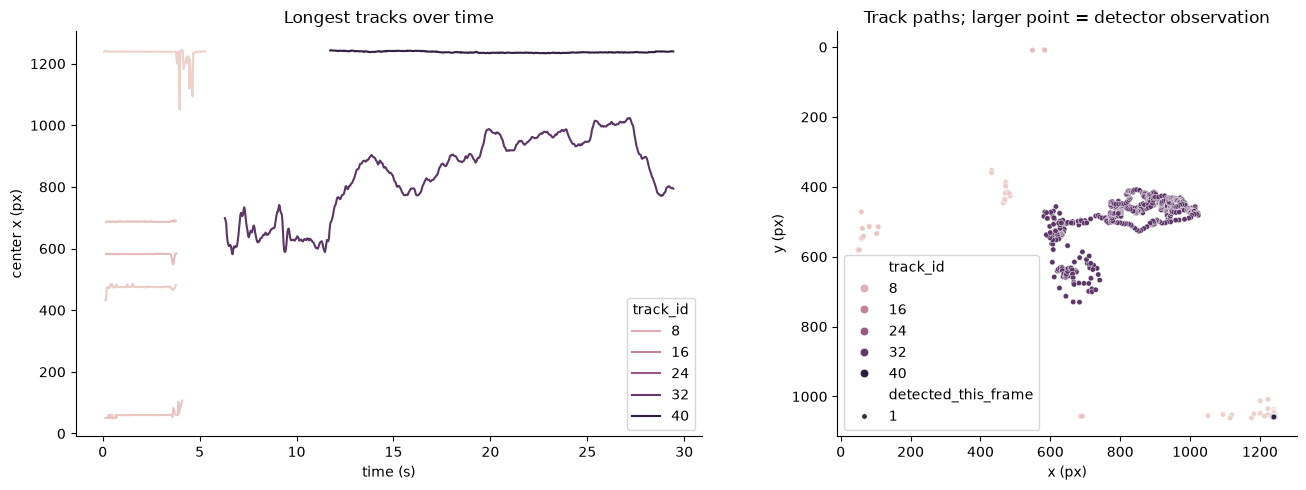

In [8]:
if objects.empty:
    print("No object rows to plot.")
else:
    objects["cx"] = objects["track_x"] + objects["track_w"] / 2
    objects["cy"] = objects["track_y"] + objects["track_h"] / 2
    display(tracks.sort_values("total_rows", ascending=False).head(20))
    valid = objects.dropna(subset=["track_id", "frame_time_s", "cx", "cy"])
    top_ids = valid["track_id"].value_counts().head(8).index
    plot_objects = valid[valid["track_id"].isin(top_ids)]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.lineplot(data=plot_objects, x="frame_time_s", y="cx", hue="track_id", estimator=None, ax=axes[0])
    axes[0].set(xlabel="time (s)", ylabel="center x (px)", title="Longest tracks over time")
    sns.scatterplot(data=plot_objects, x="cx", y="cy", hue="track_id", size="detected_this_frame", sizes=(15, 50), ax=axes[1])
    axes[1].invert_yaxis(); axes[1].set_aspect("equal", adjustable="box")
    axes[1].set(xlabel="x (px)", ylabel="y (px)", title="Track paths; larger point = detector observation")
    plt.tight_layout()


## Pose Keypoints

Keypoints are loaded from the normalized `keypoints.csv` table. Names come from the selected model package; no class or pose indices are hard-coded here.


In [9]:
def selected_pose_sidecar() -> Path:
    if RESULT_DIR != RUN_DIR:
        manifest = json.loads((RESULT_DIR / "offline_manifest.json").read_text())
        return Path(manifest["model_package"]["pose_sidecar"])
    manifest = json.loads((RUN_DIR / "run_manifest.json").read_text())
    return Path(manifest["inference"]["model_package"]["pose_sidecar"])

pose_schema = json.loads(selected_pose_sidecar().read_text())
print(f"model keypoints={pose_schema.get('keypoint_count')}")
if not keypoints.empty:
    display(keypoints.groupby("keypoint_name")["confidence"].describe().sort_values("mean", ascending=False))


model keypoints=19


,count,mean,std,min,25%,50%,75%,max
keypoint_name,,,,,,,,
back,3108.0,0.838500,0.263760,9.927750e-04,0.833130,0.937988,0.999023,1.000000
tail_base,3108.0,0.700728,0.266222,4.692078e-04,0.483398,0.681396,0.965820,1.000000
left_haunch,3108.0,0.692700,0.246078,4.573822e-03,0.457214,0.685059,0.954590,1.000000
lower_back,3108.0,0.688518,0.347122,6.933212e-04,0.258301,0.859863,0.989746,1.000000
upper_back,3108.0,0.680403,0.371063,1.309395e-03,0.619995,0.867920,0.995117,1.000000
right_haunch,3108.0,0.655907,0.329191,3.870010e-03,0.355225,0.754639,0.991211,1.000000
right_ear,3108.0,0.654047,0.390177,1.657009e-05,0.513184,0.866455,0.998047,1.000000
nose,3108.0,0.603224,0.367545,7.534027e-05,0.466980,0.620850,0.975098,1.000000
top_left_corner,1141.0,0.592250,0.296230,0.000000e+00,0.447266,0.667480,0.824707,0.987793


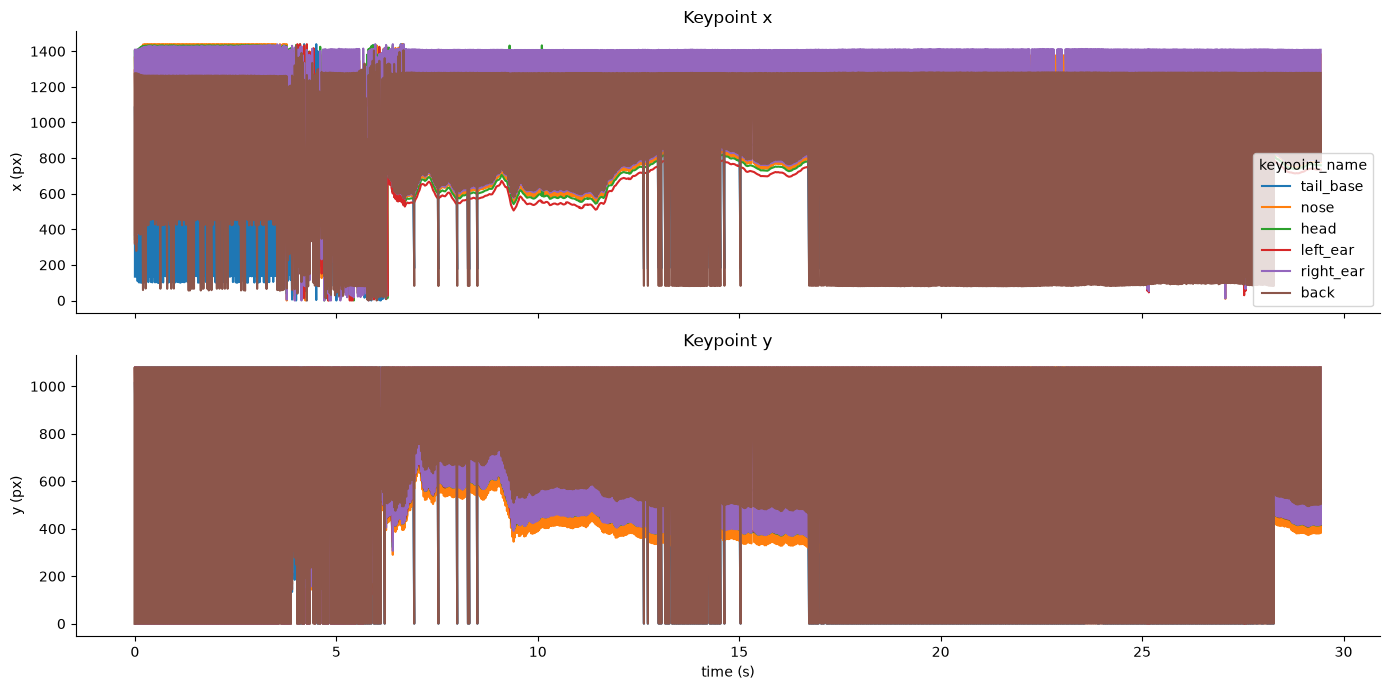

In [10]:
MIN_KEYPOINT_SCORE = float(pose_schema.get("keypoint_threshold", 0.5))
KEYPOINTS_TO_PLOT = list(keypoints["keypoint_name"].dropna().unique()[:6]) if not keypoints.empty else []

pose = keypoints[(keypoints["keypoint_name"].isin(KEYPOINTS_TO_PLOT)) & (keypoints["confidence"] >= MIN_KEYPOINT_SCORE)].copy()
if pose.empty:
    print("No keypoints pass the selected filter.")
else:
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    sns.lineplot(data=pose, x="frame_time_s", y="x_px", hue="keypoint_name", estimator=None, ax=axes[0])
    sns.lineplot(data=pose, x="frame_time_s", y="y_px", hue="keypoint_name", estimator=None, ax=axes[1], legend=False)
    axes[0].set(title="Keypoint x", ylabel="x (px)")
    axes[1].set(title="Keypoint y", xlabel="time (s)", ylabel="y (px)")
    plt.tight_layout()


## Event-aligned Inference


POKE_START locked object rows: 5,963


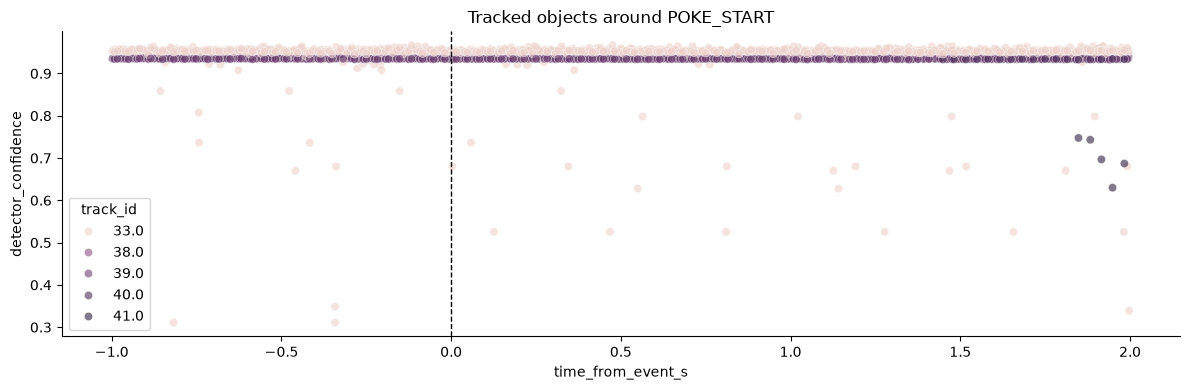

In [11]:
def event_locked_objects(event_type: str, pre_s=1.0, post_s=2.0) -> pd.DataFrame:
    anchors = events[(events["eventType"] == event_type) & events["event_time_s"].notna()]
    chunks = []
    for anchor_index, event in anchors.iterrows():
        t0 = float(event["event_time_s"])
        window = objects[objects["frame_time_s"].between(t0 - pre_s, t0 + post_s)].copy()
        window["anchor_index"] = anchor_index
        window["time_from_event_s"] = window["frame_time_s"] - t0
        chunks.append(window)
    return pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()

EVENT_TYPE = "POKE_START"
locked = event_locked_objects(EVENT_TYPE)
print(f"{EVENT_TYPE} locked object rows: {len(locked):,}")
if not locked.empty:
    sns.scatterplot(data=locked, x="time_from_event_s", y="detector_confidence", hue="track_id", alpha=.6)
    plt.axvline(0, color="black", ls="--", lw=1)
    plt.title(f"Tracked objects around {EVENT_TYPE}")
    plt.tight_layout()


## Optional Exact-frame Raw Video Preview

This preview seeks by the authoritative raw-video frame index, not an approximate timestamp. It overlays tracker boxes and normalized keypoints from the selected result.


,observation_id,stream_id,deepstream_frame_number,source_sequence_index,camera_frame_id,camera_timestamp_ns,gst_pts_ns,class_id,class_label,track_id,...,track_w,track_h,pose_available,schema_version,raw_frame_index,camera_frame_id_ledger,frame_time_s,frame_pts_ns,cx,cy
87,s0:f12:o0,0,12,12,20956,266607249457080,401636000,0,mouse,6.0,...,490.500000,15.609375,1,2,12,20956,0.40164,401636000,581.625000,7.804688
88,s0:f12:o1,0,12,12,20956,266607249457080,401636000,0,mouse,NaN,...,119.953125,325.125000,1,2,12,20956,0.40164,401636000,59.976562,548.437500
89,s0:f12:o2,0,12,12,20956,266607249457080,401636000,0,mouse,3.0,...,244.687500,155.250000,1,2,12,20956,0.40164,401636000,485.156250,423.562500
90,s0:f12:o3,0,12,12,20956,266607249457080,401636000,0,mouse,NaN,...,251.718750,144.562500,1,2,12,20956,0.40164,401636000,476.015625,415.406250
91,s0:f12:o4,0,12,12,20956,266607249457080,401636000,0,mouse,4.0,...,100.546875,312.750000,1,2,12,20956,0.40164,401636000,50.273438,581.625000
92,s0:f12:o5,0,12,12,20956,266607249457080,401636000,0,mouse,2.0,...,401.625000,67.500000,1,2,12,20956,0.40164,401636000,1239.187500,1046.250000
93,s0:f12:o6,0,12,12,20956,266607249457080,401636000,0,mouse,5.0,...,507.093750,47.250000,1,2,12,20956,0.40164,401636000,686.953125,1056.375000


,observation_id,stream_id,deepstream_frame_number,source_sequence_index,camera_frame_id,track_id,class_id,class_label,keypoint_index,keypoint_name,...,x_norm,y_norm,confidence,visible,coordinate_space,source,raw_frame_index,camera_frame_id_ledger,frame_time_s,frame_pts_ns
870,s0:f12:o0,0,12,12,20956,6.0,0,mouse,0,nose,...,0.511719,0.000000,0.824219,1,source_pixels,detector,12,20956,0.40164,401636000
871,s0:f12:o0,0,12,12,20956,6.0,0,mouse,1,head,...,0.507031,0.000000,0.966797,1,source_pixels,detector,12,20956,0.40164,401636000
872,s0:f12:o0,0,12,12,20956,6.0,0,mouse,2,left_ear,...,0.489063,0.000000,0.962891,1,source_pixels,detector,12,20956,0.40164,401636000
873,s0:f12:o0,0,12,12,20956,6.0,0,mouse,3,right_ear,...,0.515625,0.000000,0.926758,1,source_pixels,detector,12,20956,0.40164,401636000
874,s0:f12:o0,0,12,12,20956,6.0,0,mouse,4,back,...,0.389453,0.000000,1.000000,1,source_pixels,detector,12,20956,0.40164,401636000
875,s0:f12:o0,0,12,12,20956,6.0,0,mouse,5,tail_base,...,0.276562,0.000000,0.958984,1,source_pixels,detector,12,20956,0.40164,401636000
876,s0:f12:o0,0,12,12,20956,6.0,0,mouse,15,upper_back,...,0.460156,0.000000,0.997559,1,source_pixels,detector,12,20956,0.40164,401636000
877,s0:f12:o0,0,12,12,20956,6.0,0,mouse,16,lower_back,...,0.328320,0.000000,0.997559,1,source_pixels,detector,12,20956,0.40164,401636000
878,s0:f12:o0,0,12,12,20956,6.0,0,mouse,17,left_haunch,...,0.346094,0.000000,0.996582,1,source_pixels,detector,12,20956,0.40164,401636000
879,s0:f12:o0,0,12,12,20956,6.0,0,mouse,18,right_haunch,...,0.326172,0.000000,0.969238,1,source_pixels,detector,12,20956,0.40164,401636000


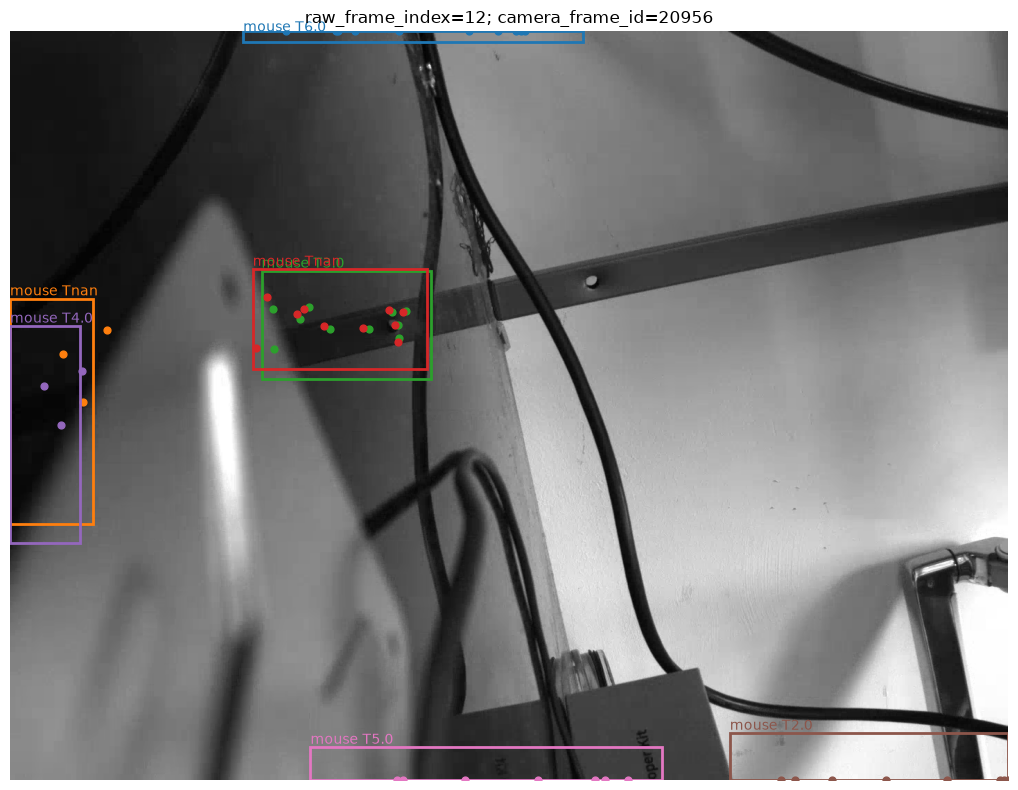

In [17]:
RUN_PREVIEW = True
RAW_FRAME_INDEX_TO_PREVIEW = 12
# RAW_FRAME_INDEX_TO_PREVIEW = int(frames.iloc[len(frames) // 2]["raw_frame_index"]) if len(frames) else 0
KEYPOINT_SCORE_THRESHOLD = float(pose_schema.get("keypoint_threshold", 0.5))

if RUN_PREVIEW:
    frame_match = frames[frames["raw_frame_index"] == RAW_FRAME_INDEX_TO_PREVIEW]
    if frame_match.empty:
        raise ValueError(f"No ledger row for raw_frame_index={RAW_FRAME_INDEX_TO_PREVIEW}")
    frame_row = frame_match.iloc[0]
    video_path = RUN_DIR / "raw.mp4"
    local_index = int(frame_row.get("video_frame_index", frame_row["raw_frame_index"] - frames["raw_frame_index"].min()))
    out_png = RESULT_DIR / f"preview_raw_{RAW_FRAME_INDEX_TO_PREVIEW:06d}.png"
    subprocess.run([
        "ffmpeg", "-y", "-hide_banner", "-loglevel", "error", "-i", str(video_path),
        "-vf", f"select=eq(n\\,{local_index})", "-vsync", "0", "-frames:v", "1", str(out_png),
    ], check=True)

    frame_objects = objects[objects["source_sequence_index"] == RAW_FRAME_INDEX_TO_PREVIEW]
    frame_points = keypoints[(keypoints["source_sequence_index"] == RAW_FRAME_INDEX_TO_PREVIEW) & (keypoints["confidence"] >= KEYPOINT_SCORE_THRESHOLD)]
    image = plt.imread(out_png)
    fig, ax = plt.subplots(figsize=(12, 8)); ax.imshow(image, cmap="gray")
    cmap = plt.get_cmap("tab10")
    for ordinal, (_, obj) in enumerate(frame_objects.iterrows()):
        color = cmap(ordinal % 10)
        ax.add_patch(Rectangle((obj["track_x"], obj["track_y"]), obj["track_w"], obj["track_h"], fill=False, edgecolor=color, lw=2))
        ax.text(obj["track_x"], max(0, obj["track_y"] - 5), f"{obj['class_label']} T{obj['track_id']}", color=color)
        points = frame_points[frame_points["observation_id"] == obj["observation_id"]]
        ax.scatter(points["x_px"], points["y_px"], color=[color], s=24)
    ax.set_title(f"raw_frame_index={RAW_FRAME_INDEX_TO_PREVIEW}; camera_frame_id={int(frame_row['camera_frame_id'])}")
    ax.set_xlim(0, image.shape[1]); ax.set_ylim(image.shape[0], 0); ax.axis("off")
    plt.tight_layout()
    display(frame_objects, frame_points)
else:
    print("Preview disabled. Set RUN_PREVIEW=True and choose RAW_FRAME_INDEX_TO_PREVIEW.")
